# HCI Car Simulation_Data Analysis

In [34]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import re
import pandas as pd
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from scripts import twoddynamics, oneddynamics, databuilder, readsubcategoryrating


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# %config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

# 0. Load data and write data dictionary

In [27]:
phase = "phaseI"
sub_nums = np.arange(1,13,1)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir = DATA_DIR / phase

df_phase = pd.read_csv(data_dir / "PhaseI_Block.csv")
df_pattern = pd.read_csv(data_dir / "RecommendationPatterns.csv")

df_subcategory_rating = pd.read_csv(data_dir / "Rating_subcategory.csv")

df_subcategory_rating = readsubcategoryrating.format(df_subcategory_rating)

In [29]:
data_dict = defaultdict(dict)

for sub in sub_nums:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 3, f"sub{sub} has more than 3 folders"

    for j, sub_dir in enumerate(sub_dirs):
        block = j + 4 if sub % 2 == 0 else j + 1
        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        sub_rating = df_subcategory_rating[(df_subcategory_rating["sub_id"] == sub) & (df_subcategory_rating["block_id"] == block)]

        scene_key = f"scene_{row['SceneID']}"

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        data_dict[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "subcategory_rating": sub_rating,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

In [6]:
def build_trial_level_df(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")

            df["accept_bin"] = (df["reaction"] == "accept").astype(int)

            for _, row in df.iterrows():
                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(row["type"]),
                    "accept": row["accept_bin"]
                })

    return pd.DataFrame(records)

df_trial = build_trial_level_df(data_dict)

# 1. Mixed Effect Modeling
## 1.1 LMM treat sub as random intercept

In [411]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"]
)

result = model.fit()
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          358              Method:                      REML     
No. Groups:                12               Scale:                       0.1946   
Min. group size:           28               Log-Likelihood:              -232.3901
Max. group size:           30               Converged:                   Yes      
Mean group size:           29.8                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.200    0.184  6.519 0.000  0.839  1.561
driving[T.manual]                       -0.233    0.260 -0.896 0.370 -0.744  0.277
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 1.1 Treat Type Independently

In [412]:
for t in [1, 2]:
    df_sub = df_trial[df_trial["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ driving * scene",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())


=== Type 1 ===
                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        accept  
No. Observations:          179            Method:                    REML    
No. Groups:                12             Scale:                     0.1630  
Min. group size:           14             Log-Likelihood:            -98.9089
Max. group size:           15             Converged:                 No      
Mean group size:           14.9                                              
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.900    0.074 12.147 0.000  0.755  1.045
driving[T.manual]                  -0.067    0.105 -0.636 0.525 -0.272  0.139
scene[T.scene_2]                   -0.072    0.105 -0.688 0.491 -0.2

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

## 1.2 LMM treat sub as random slope

In [413]:
model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"],
    re_formula="~type"
)

result = model.fit()
print(result.summary())

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          358              Method:                      REML     
No. Groups:                12               Scale:                       0.1844   
Min. group size:           28               Log-Likelihood:              -244.1729
Max. group size:           30               Converged:                   No       
Mean group size:           29.8                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.200    0.198  6.063 0.000  0.812  1.588
driving[T.manual]                       -0.233    0.280 -0.834 0.404 -0.782  0.315
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2218:

# 2. Acceptance rate description

In [414]:
def extract_reaction_stats(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")
            df["pattern"] = df["current_encode_id"].astype(str)
            df["type_sub"] = df["pattern"].str[1:3]

            for t in ["1", "2"]:
                sub_df = df[df["type"] == t]
                if len(sub_df) == 0:
                    continue

                total = len(sub_df)
                counts = sub_df["reaction"].value_counts()

                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(t),
                    "accept": counts.get("accept", 0)/total,
                    "reject": counts.get("reject", 0)/total,
                    "ignore": counts.get("ignore", 0)/total,
                })

    return pd.DataFrame(records)

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

type_palette = {
    1: "#1D9CFF",
    2: "#FFA51C",
}

driving_mode_palette = {
    'auto': "#651DFF",
    'manual': "#FFA51C",
}

def plot_scene_box(df):
    for metric in ["accept", "reject", "ignore"]:
        for t in [1, 2]:
            plt.figure(figsize=(8,5))
            sns.boxplot(
                data=df[df["type"]==t],
                x="scene",
                y=metric,
                hue="driving"
            )
            plt.title(f"{metric} (Type {t}) across scenes")
            plt.xticks(rotation=30)
            plt.show()

def plot_scene_facet(df):
    for metric in ["accept", "reject", "ignore"]:
        g = sns.catplot(
            data=df,
            x="scene",
            y=metric,
            hue="driving",
            col="type",
            kind="box",
            height=4,
            aspect=1.2
        )
        g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=30)
        plt.show()

def plot_type_facet(df):
    for metric in ["accept"]:
        g = sns.catplot(
            data=df,
            x="type",
            y=metric,
            hue="type",
            palette=type_palette,
            col="scene",
            kind="bar",
            errorbar="se",
            height=3,
            aspect=0.5,
            legend=False,
        )
        
        # g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        g.set_xticklabels(["type 1", "type 2"])
        g.set_axis_labels("", f"{metric} ratio")

        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=0)
            ax.set_ylim(0, 1)
            ax.set_yticks(np.linspace(0, 1, 6))
        
        plt.show()

In [416]:
from scipy.stats import mannwhitneyu, wilcoxon

def summarize_scene(df):
    summary = df.groupby(["scene","driving","type"]).agg(
        accept_mean=("accept","mean"),
        reject_mean=("reject","mean"),
        ignore_mean=("ignore","mean"),
        n=("sub","count")
    ).reset_index()

    print(summary)
    return summary

from scipy.stats import mannwhitneyu

def test_driving_per_scene(df):
    print("\n=== Driving effect per scene ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for scene in df["scene"].unique():
            for t in [1,2]:
                sub_df = df[(df["scene"]==scene) & (df["type"]==t)]

                g1 = sub_df[sub_df["driving"]=="manual"][metric]
                g2 = sub_df[sub_df["driving"]=="auto"][metric]

                if len(g1)>0 and len(g2)>0:
                    _, p = mannwhitneyu(g1, g2)
                    print(f"{scene}, type{t}: p={p:.4f}")

from scipy.stats import friedmanchisquare

def test_scene_effect(df):
    print("\n=== Scene effect ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index="sub",
                columns="scene",
                values=metric
            ).dropna()

            if pivot.shape[1] >= 3:
                stat, p = friedmanchisquare(*[pivot[c] for c in pivot.columns])
                print(f"type{t}: p={p:.4f}")

def test_interaction_proxy(df):
    print("\n=== Interaction proxy (Δscene effect between driving) ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index=["sub","driving"],
                columns="scene",
                values=metric
            ).dropna()

            pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)

            manual = pivot[pivot.index.get_level_values("driving")=="manual"]["range"]
            auto   = pivot[pivot.index.get_level_values("driving")=="auto"]["range"]

            if len(manual)>0 and len(auto)>0:
                _, p = mannwhitneyu(manual, auto)
                print(f"type{t}: p={p:.4f}")

from scipy.stats import mannwhitneyu

def test_scene_type_diff(df):
    print("\n=== Type1 vs Type2 difference within each scene ===")

    for metric in ["accept", "reject", "ignore"]:
        print(f"\n--- {metric} ---")

        for scene in sorted(df["scene"].unique()):
            scene_df = df[df["scene"] == scene]

            type1 = scene_df.loc[scene_df["type"] == 1, metric].dropna()
            type2 = scene_df.loc[scene_df["type"] == 2, metric].dropna()

            if len(type1) > 0 and len(type2) > 0:
                stat, p = mannwhitneyu(type1, type2, alternative="two-sided")
                print(
                    f"{scene}: "
                    f"type1(n={len(type1)}, mean={type1.mean():.3f}, median={type1.median():.3f}) | "
                    f"type2(n={len(type2)}, mean={type2.mean():.3f}, median={type2.median():.3f}) | "
                    f"U={stat:.3f}, p={p:.4f}"
                )
            else:
                print(f"{scene}: insufficient data")

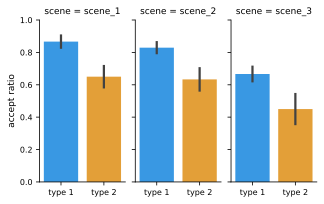

      scene driving  type  accept_mean  reject_mean  ignore_mean  n
0   scene_1    auto     1     0.900000     0.033333     0.066667  6
1   scene_1    auto     2     0.600000     0.366667     0.033333  6
2   scene_1  manual     1     0.833333     0.066667     0.100000  6
3   scene_1  manual     2     0.700000     0.166667     0.133333  6
4   scene_2    auto     1     0.825000     0.075000     0.100000  6
5   scene_2    auto     2     0.566667     0.400000     0.033333  6
6   scene_2  manual     1     0.833333     0.133333     0.033333  6
7   scene_2  manual     2     0.700000     0.200000     0.100000  6
8   scene_3    auto     1     0.733333     0.200000     0.066667  6
9   scene_3    auto     2     0.400000     0.566667     0.033333  6
10  scene_3  manual     1     0.600000     0.200000     0.200000  6
11  scene_3  manual     2     0.500000     0.333333     0.166667  6

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_1: type1(n=12, mean=0.867, median=0.800) 

In [417]:
df_stats = extract_reaction_stats(data_dict)

# plot_scene_facet(df_stats)
plot_type_facet(df_stats)

summary = summarize_scene(df_stats)

# test_driving_per_scene(df_stats)
# test_scene_effect(df_stats)
# test_interaction_proxy(df_stats)
test_scene_type_diff(df_stats)

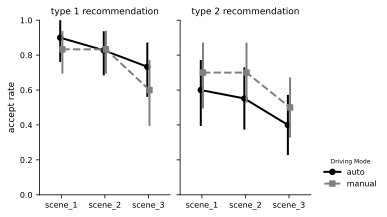

In [418]:
df_trial["driving"] = df_trial["driving"].astype("category")
df_trial["scene"] = df_trial["scene"].astype("category")
df_trial["type"] = df_trial["type"].astype("category")

# plt.figure(figsize=(3,3))

g = sns.catplot(
    data=df_trial,
    x="scene",
    y="accept",
    hue="driving",
    col="type",
    kind="point",
    dodge=True,
    errorbar=('ci', 95),
    height=3,
    aspect=0.6,
    palette=["black", "gray"],
    markers=["o", "s"],
    linestyles=["-", "--"],
    linewidth = 2.0,
)

g.set_axis_labels("", "accept rate")
g.set_titles("type {col_name} recommendation")
g._legend.set_bbox_to_anchor((1.0, 0.1))
g._legend.set_loc("lower left")
g._legend.set_title("Driving Mode")
# g.fig.suptitle(
#     "Accept Rate by Scene, Driving Mode, and Type",
#     y=1.0,
#     ha='center'
# )

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))

plt.tight_layout()
plt.show()

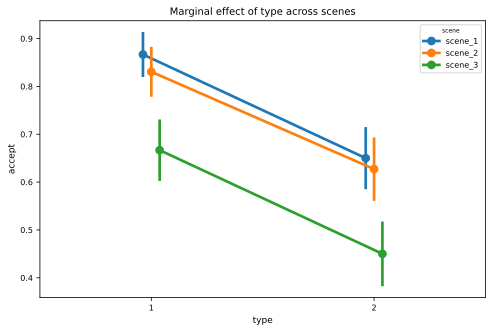

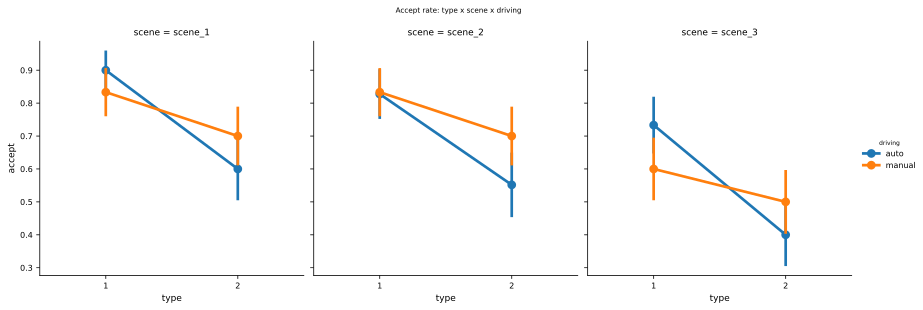

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_3072/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_3072/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_3072/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain

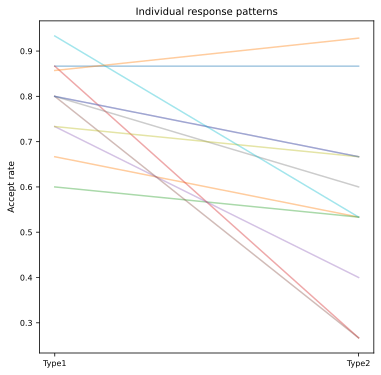

In [419]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="scene",
    dodge=True,
    errorbar="se"
)

plt.title("Marginal effect of type across scenes")
plt.show()

g = sns.catplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="driving",
    col="scene",
    kind="point",
    errorbar="se",
    height=4,
    aspect=1,
)

g.fig.suptitle("Accept rate: type x scene x driving", y=1.05)
plt.show()

plt.figure(figsize=(6,6))

for sub in df_trial["sub"].unique():
    sub_df = df_trial[df_trial["sub"]==sub]
    pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")

    plt.plot([1,2], pivot.values.flatten(), alpha=0.4)

plt.xticks([1,2], ["Type1", "Type2"])
plt.ylabel("Accept rate")
plt.title("Individual response patterns")
plt.show()

## 3. Subject clustering

In [420]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot.columns = ["accept_type1", "accept_type2"]
pivot["diff"] = pivot["accept_type1"] - pivot["accept_type2"]

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_3072/1223868461.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


In [421]:
from sklearn.cluster import KMeans

X = pivot[["accept_type1", "accept_type2"]].values

kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
pivot["cluster"] = kmeans.labels_

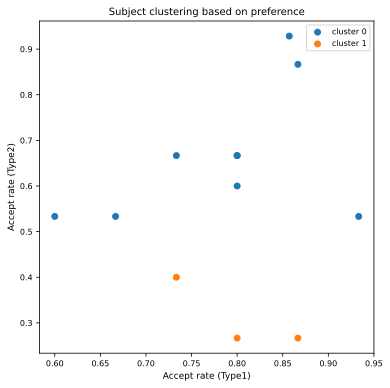

In [422]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for c in pivot["cluster"].unique():
    sub_df = pivot[pivot["cluster"]==c]
    plt.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )

plt.xlabel("Accept rate (Type1)")
plt.ylabel("Accept rate (Type2)")
plt.legend()
plt.title("Subject clustering based on preference")
plt.show()

In [423]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot["diff"] = pivot[1] - pivot[2]
print(pivot)

type         1         2      diff
sub                               
1     0.866667  0.866667  0.000000
2     0.666667  0.533333  0.133333
3     0.600000  0.533333  0.066667
4     0.866667  0.266667  0.600000
5     0.733333  0.400000  0.333333
6     0.800000  0.266667  0.533333
7     0.800000  0.666667  0.133333
8     0.800000  0.600000  0.200000
9     0.733333  0.666667  0.066667
10    0.933333  0.533333  0.400000
11    0.800000  0.666667  0.133333
12    0.857143  0.928571 -0.071429


/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_3072/1211643864.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


# 4. Per-reaction modeling

For each reaction, we aggregate trial-level features into the following groups.

---

### Meta

- `sub_id`: subject ID (`int`)
- `scene_id`: scene ID (`int`)
- `mode`: driving mode (`int`)
- `recommendation`: recommendation code (`int`, 5 digits)
- `recommendation_category`: recommendation category (`int`, 1 digit)
- `recommendation_subcategory`: recommendation subcategory (`int`, 3 digits)

---

### Prior

These variables describe the participant’s baseline tendency and behavioral state before the current recommendation.

- `subject_prior_accept_prob_subcategory`: subject-level prior probability of accepting this recommendation subcategory (`float`)
- `mean_steering_input`: mean steering input (`float`)
- `var_steering_input`: variance of steering input (`float`)
- `mean_throttle_input`: mean throttle input (`float`)
- `var_throttle_input`: variance of throttle input (`float`)

---

### Scenario

These variables describe the current recommendation and the driving context around the reaction.

- `intensity`: intensity of the recommendation (`float`)
- `coherence`: coherence of the recommendation (`float`)
- `mean_steering_input_zscore_pre2s`: mean steering input z-score in the 2 s pre-reaction window (`float`)
- `mean_throttle_input_zscore_pre2s`: mean throttle input z-score in the 2 s pre-reaction window (`float`)

---

### Reaction

These variables describe the behavioral response to the recommendation.

- `accept`: whether the recommendation was accepted (`bool`)
- `reaction_time_ms`: reaction time in milliseconds (`float`)
- `mean_steering_input_zscore_post5s`: mean steering input z-score in the 5 s post-reaction window (`float`)
- `mean_throttle_input_zscore_post5s`: mean throttle input z-score in the 5 s post-reaction window (`float`)

---

### Evaluation

These variables describe the participant’s subjective evaluation after the reaction.

- `disturbance`: perceived disturbance (`float`)
- `satisfaction`: subjective satisfaction (`float`)
- `appropriateness`: perceived appropriateness (`float`)

---

## Dynamic Modeling Goal

We build a dynamical decision model that takes **prior** and **scenario** variables as inputs to predict whether a recommendation is **accepted**.

The model is designed to capture the competition between latent **accept** and **reject** decision states over time.

---

## Modeling Assumption

We assume that the biological time constant of the decision dynamics is the same across participants.

In other words:

- the accept-state time constant is shared across subjects
- the reject-state time constant is shared across subjects

This means that individual differences are modeled mainly through:

- prior acceptance tendency
- scenario-dependent inputs
- reaction-specific context

rather than through subject-specific intrinsic time constants.


In [30]:
df_reaction = databuilder.build_per_reaction_df(
    data_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
)

# print(df_reaction["prior_mean_throttle_input"].head())

reaction_data_dict = databuilder.build_per_reaction_data_dict(df_reaction)

## 4.1 Subcategory Disturbance, Satisfaction and Appropriateness

In [41]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

df = df_reaction.copy()

df["scene_id"] = df["scene_id"].astype("category")
df["mode"] = df["mode"].astype("category")
df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")
df["sub_id"] = df["sub_id"].astype("category")

metrics = ["appropriateness", "disturbance", "satisfaction"]

In [ ]:
overall_results = []

for metric in metrics:
    formula = f"{metric} ~ recommendation_subcategory * scene_id * mode"
    model_all = smf.mixedlm(
        formula,
        df,
        groups=df["sub_id"]
    ).fit(reml=False)

    print("\n" + "="*80)
    print(f"OVERALL MODEL FOR {metric}")
    print("="*80)
    print(model_all.summary())

    coef_table = pd.DataFrame({
        "term": model_all.params.index,
        "coef": model_all.params.values,
        "pval": model_all.pvalues.values
    })
    coef_table["metric"] = metric
    overall_results.append(coef_table)

overall_results_df = pd.concat(overall_results, ignore_index=True)


OVERALL MODEL FOR appropriateness
                                     Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 appropriateness
No. Observations:                   358                     Method:                             ML             
No. Groups:                         12                      Scale:                              1.7796         
Min. group size:                    28                      Log-Likelihood:                     -623.7480      
Max. group size:                    30                      Converged:                          Yes            
Mean group size:                    29.8                                                                       
---------------------------------------------------------------------------------------------------------------
                                                                     Coef.  Std.Err.   z    P>|z| [0.025 0

In [48]:
per_subcat_results = []
per_subcat_models = {}

for subcat in df["recommendation_subcategory"].cat.categories:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    for metric in metrics:
        formula = f"{metric} ~ scene_id * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)
per_subcat_results_df.head()

def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for keys, idx in grouped.groups.items():
        pvals = df_out.loc[idx, p_col].values.astype(float)
        mask = ~np.isnan(pvals)
        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            df_out.loc[np.array(idx)[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)

summary_rows = []

for subcat in df["recommendation_subcategory"].cat.categories:
    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        scene_terms = df_tmp[df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
                             ~df_tmp["term"].str.contains(":", regex=False, na=False)]

        mode_terms = df_tmp[df_tmp["term"].str.contains("mode", regex=False, na=False) &
                            ~df_tmp["term"].str.contains(":", regex=False, na=False)]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id") &
            df_tmp["term"].str.contains("mode") &
            df_tmp["term"].str.contains(":")
        ]

        summary_rows.append({
            "subcategory": subcat,
            "metric": metric,
            "scene_min_p": scene_terms["pval"].min() if len(scene_terms) else np.nan,
            "scene_min_p_fdr": scene_terms["pval_fdr"].min() if len(scene_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["metric", "subcategory"]).reset_index(drop=True)
summary_df

,subcategory,metric,scene_min_p,scene_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr
0,101,appropriateness,0.069023,0.567233,0.586982,0.838546,0.668236,0.742484
1,102,appropriateness,0.126859,0.211432,0.855873,0.855873,0.826571,0.852962
2,103,appropriateness,0.478819,0.598524,0.839172,0.855873,0.133013,0.324165
3,104,appropriateness,0.126771,0.211432,0.466125,0.838546,0.130632,0.324165
4,105,appropriateness,0.000015,0.000147,0.179713,0.838546,0.003695,0.036953
5,201,appropriateness,0.001109,0.005544,0.511115,0.838546,0.214327,0.410235
6,202,appropriateness,0.009195,0.030649,0.694265,0.855873,0.188313,0.324165
7,203,appropriateness,0.408197,0.583138,0.323308,0.838546,0.223774,0.606537
8,204,appropriateness,0.332765,0.723173,0.031415,0.314148,0.026025,0.130123
9,205,appropriateness,0.066539,0.166346,0.429795,0.838546,0.194499,0.324165


In [49]:
from itertools import combinations
from scipy.stats import ttest_rel

pairwise_rows = []

for metric in metrics:
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    wide = agg.pivot(index="sub_id", columns="recommendation_subcategory", values=metric)

    for a, b in combinations(wide.columns, 2):
        paired = wide[[a, b]].dropna()
        if len(paired) >= 2:
            stat, pval = ttest_rel(paired[a], paired[b])
            pairwise_rows.append({
                "metric": metric,
                "subcat_a": a,
                "subcat_b": b,
                "n_subjects": len(paired),
                "mean_a": paired[a].mean(),
                "mean_b": paired[b].mean(),
                "mean_diff": (paired[a] - paired[b]).mean(),
                "pval": pval
            })

pairwise_df = pd.DataFrame(pairwise_rows)

# FDR per metric
pairwise_df["pval_fdr"] = np.nan
for metric in metrics:
    idx = pairwise_df["metric"] == metric
    if idx.sum() > 0:
        pairwise_df.loc[idx, "pval_fdr"] = multipletests(
            pairwise_df.loc[idx, "pval"],
            method="fdr_bh"
        )[1]

pairwise_df = pairwise_df.sort_values(["metric", "pval_fdr"])
pairwise_df.head(20)

,metric,subcat_a,subcat_b,n_subjects,mean_a,mean_b,mean_diff,pval,pval_fdr
3,appropriateness,101,105,12,6.694444,5.000000,1.694444,0.000691,0.009749
5,appropriateness,101,202,12,6.694444,4.666667,2.027778,0.000693,0.009749
6,appropriateness,101,203,12,6.694444,4.472222,2.222222,0.000537,0.009749
7,appropriateness,101,204,12,6.694444,4.472222,2.222222,0.000867,0.009749
4,appropriateness,101,201,12,6.694444,4.750000,1.944444,0.001724,0.015520
2,appropriateness,101,104,12,6.694444,5.583333,1.111111,0.004346,0.030956
20,appropriateness,103,202,12,5.861111,4.666667,1.194444,0.005257,0.030956
26,appropriateness,104,202,12,5.583333,4.666667,0.916667,0.005503,0.030956
8,appropriateness,101,205,12,6.694444,5.500000,1.194444,0.007798,0.038991
15,appropriateness,102,204,12,6.083333,4.472222,1.611111,0.008820,0.039692


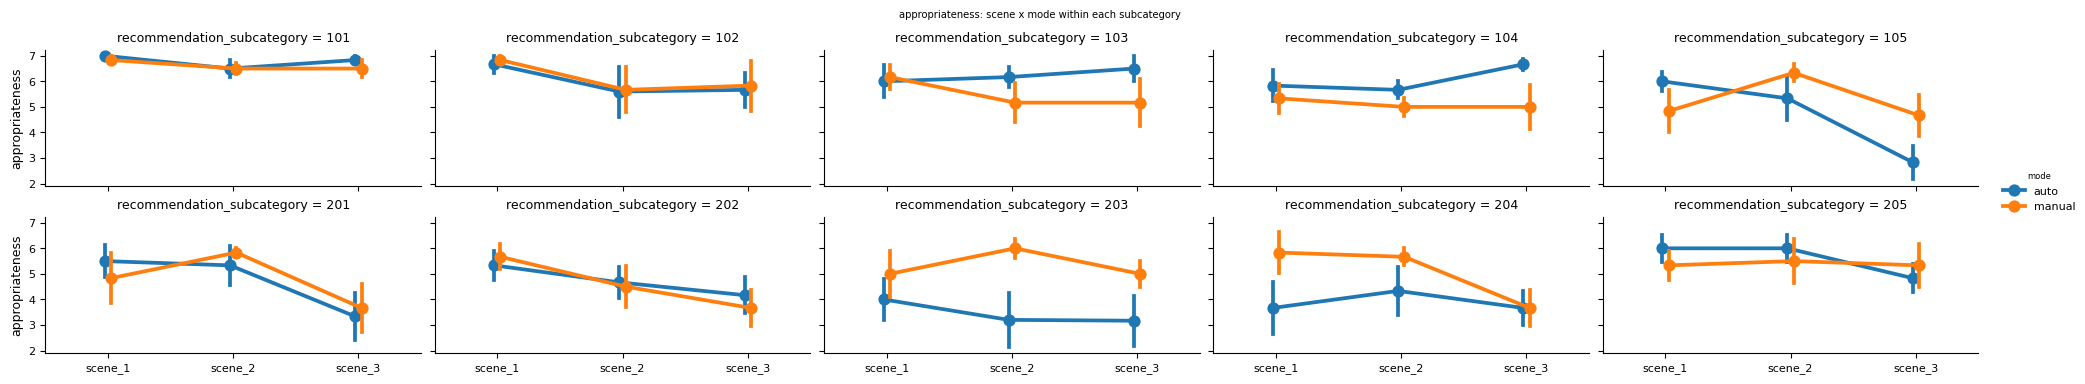

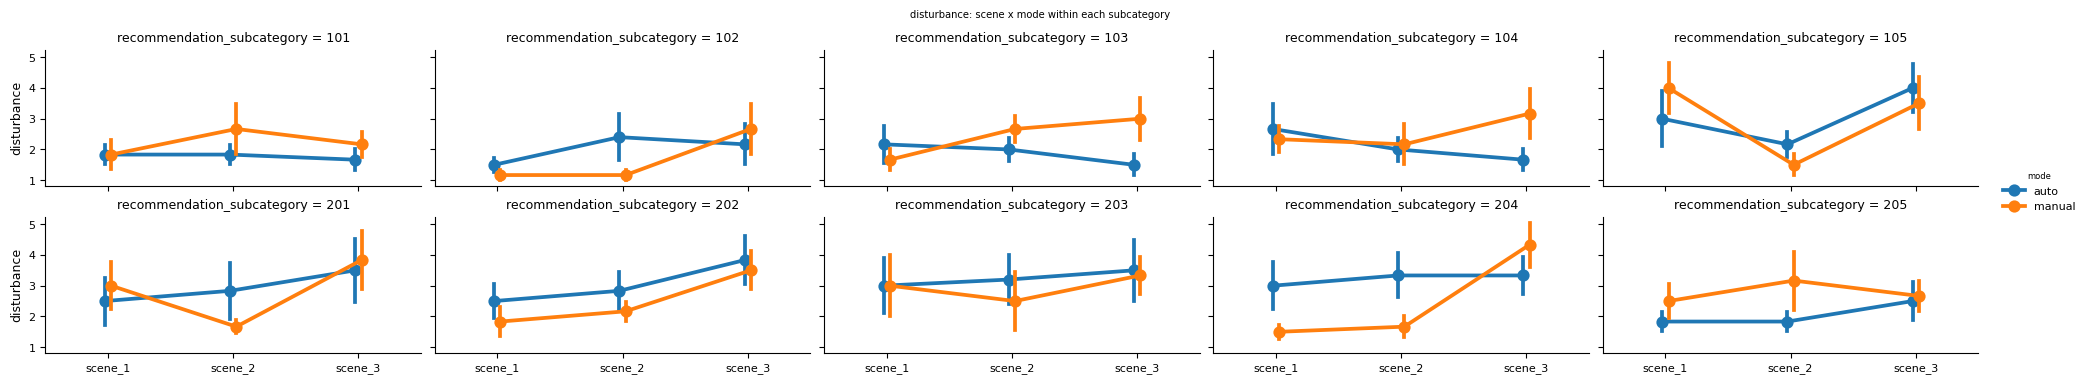

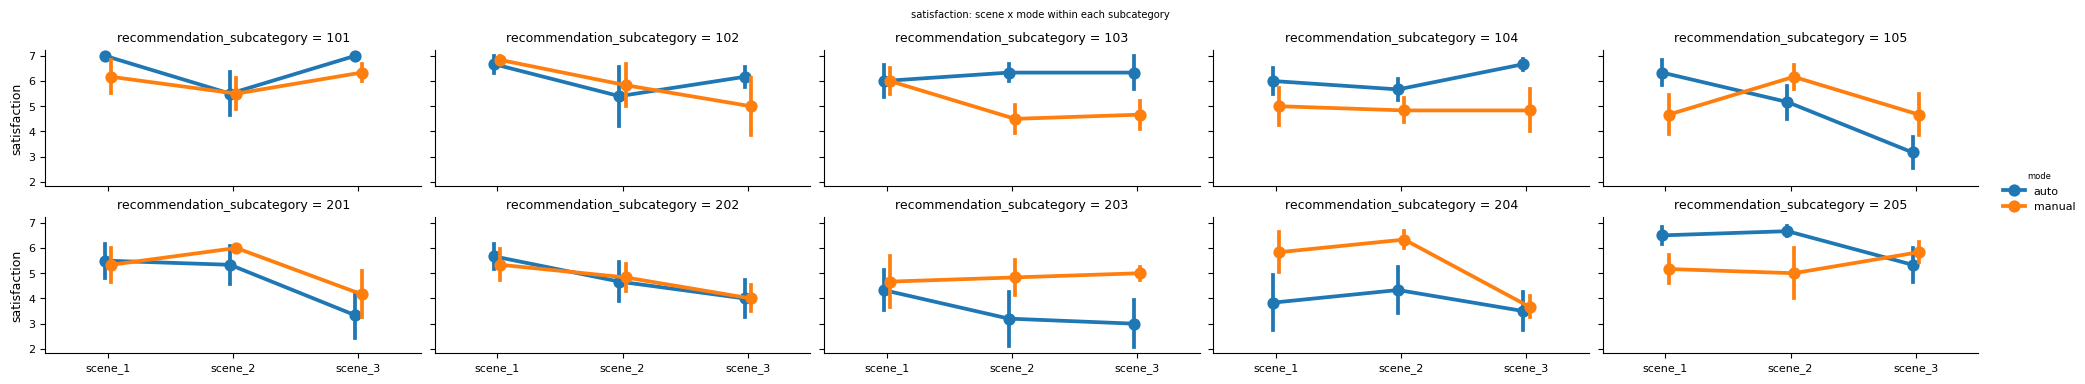

In [73]:
for metric in metrics:
    g = sns.catplot(
        data=df,
        x="scene_id",
        y=metric,
        hue="mode",
        col="recommendation_subcategory",
        kind="point",
        errorbar="se",
        dodge=True,
        col_wrap=5,
        height=2,
        aspect=2
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f"{metric}: scene x mode within each subcategory")
    for ax in g.axes.flat:
        ax.set_xlabel("")
    plt.show()

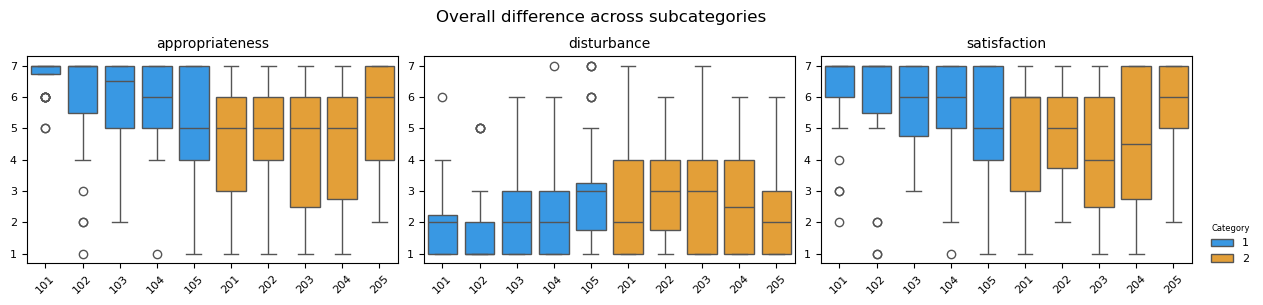

In [100]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=df,
        x="recommendation_subcategory",
        y=metric,
        color="lightblue",
        hue="recommendation_category",
        palette=type_palette,
        ax=ax
    )
    # sns.stripplot(
    #     data=df,
    #     x="recommendation_subcategory",
    #     y=metric,
    #     color="black",
    #     alpha=0.25,
    #     size=3
    # )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()

        ax.get_legend().remove()

fig.suptitle("Overall difference across subcategories", fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(handles, labels, title="Category", loc="lower left", bbox_to_anchor=(1.0, 0.1), frameon=False)

plt.show()

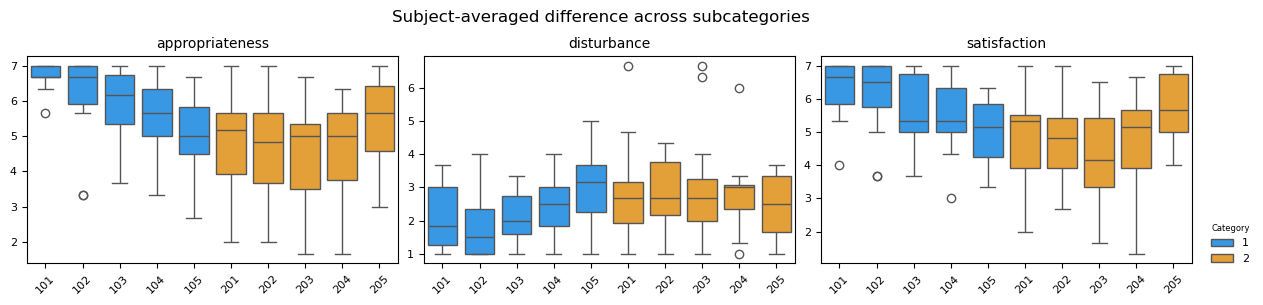

In [95]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=agg,
        x="recommendation_subcategory",
        y=metric,
        hue="category",
        palette=type_palette,
        ax=ax
    )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()

        ax.get_legend().remove()

fig.suptitle("Subject-averaged difference across subcategories", fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(handles, labels, title="Category", loc="lower left", bbox_to_anchor=(1.0, 0.1), frameon=False)

plt.show()

In [102]:
df[["appropriateness", "disturbance", "satisfaction"]].corr()

,appropriateness,disturbance,satisfaction
appropriateness,1.000000,-0.686882,0.882739
disturbance,-0.686882,1.000000,-0.740141
satisfaction,0.882739,-0.740141,1.000000


## 4.2 Baseline Model: logistic regression and svm

In [542]:
features = [
    "subject_prior_accept_prob_subcategory",
    "intensity",
    "coherence",
    "var_throttle_pre2s",
    "car_density",
    "time_pressure",
]

target = "accept"

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = df_reaction[features].copy()
y = df_reaction[target].astype(int)

X["time_pressure"] = X["time_pressure"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.7361111111111112
AUC: 0.6752440106477373
              precision    recall  f1-score   support

           0       0.64      0.39      0.49        23
           1       0.76      0.90      0.82        49

    accuracy                           0.74        72
   macro avg       0.70      0.64      0.65        72
weighted avg       0.72      0.74      0.72        72



In [544]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(probability=True, kernel="rbf"))
])

pipe_svm.fit(X_train, y_train)

y_pred_svm = pipe_svm.predict(X_test)
y_prob_svm = pipe_svm.predict_proba(X_test)[:, 1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM AUC:", roc_auc_score(y_test, y_prob_svm))

SVM Accuracy: 0.7083333333333334
SVM AUC: 0.7027506654835847


In [545]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_dummy))

Dummy Accuracy: 0.6805555555555556


In [546]:
import pandas as pd

coef = pipe.named_steps["clf"].coef_[0]
feature_importance = pd.Series(coef, index=features).sort_values()

print(feature_importance)

time_pressure                           -0.458991
car_density                             -0.043642
var_throttle_pre2s                      -0.027373
intensity                                0.000000
coherence                                0.000000
subject_prior_accept_prob_subcategory    1.070248
dtype: float64


## 4.3 1d Dynamics Simulation

The latent decision state `x` evolves as:

`change in x = leak + nonlinear term + input drive + noise`

More specifically:

`dx/dt = -lam * x + a * tanh(gain * (x - theta_dyn)) + u + noise`

where:

- `lam`: how strongly the state decays back
- `a`: strength of nonlinear attraction
- `gain`: steepness of the nonlinearity
- `theta_dyn`: center of the nonlinear curve
- `u`: evidence / pressure input
- `noise`: random fluctuation

Initial state:

`x0 = kappa * logit(p0)`

Decision readout:

`p_accept = sigmoid(x_final - theta_readout)`

Important:

- `theta_dyn` is part of the dynamics
- `theta_readout` is the final decision threshold
- nullcline means `dx/dt = 0`

scene_id :scene_2, mode: auto, subcatgory: 202
===== Single Trial Demo (1D) =====
model = nonlinear_tanh
prior p0 = 0.267
x0 = -1.012
u = 0.260
lam_eff = 1.440
sigma_eff = 0.081
gain_eff = 2.500
theta_dyn = 0.000
theta_readout = 0.000
x_final = -1.395
p_accept = 0.199
predicted accept = 0
fixed points:
  x* = -1.344, stable, slope=-1.413
  x* = -0.065, unstable, slope=3.918
  x* = 1.708, stable, slope=-1.436


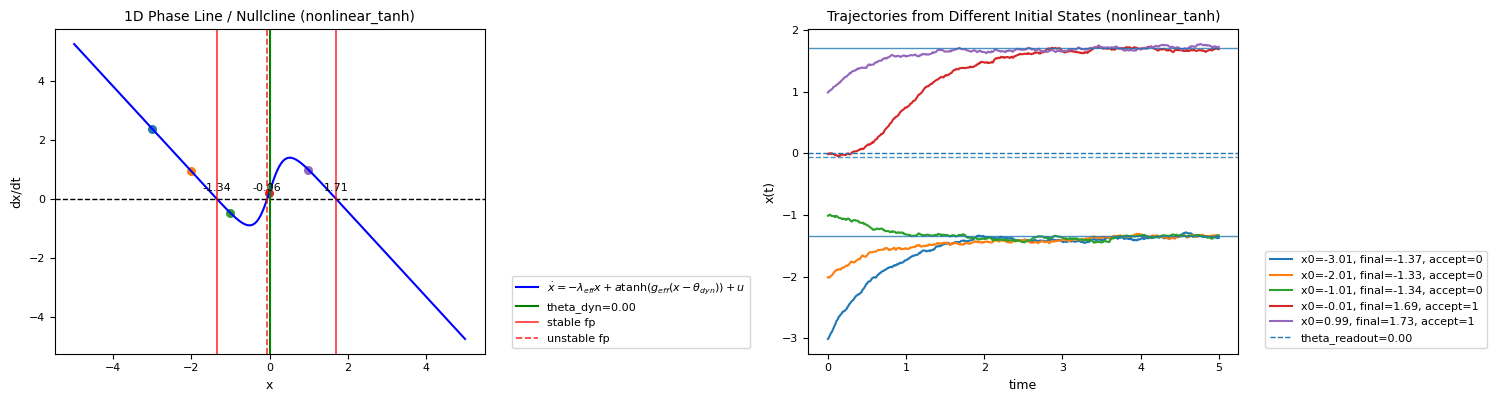

In [56]:
row = df_reaction.iloc[100]
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")


result = oneddynamics.run_single_trial_demo(
    row,
    model="nonlinear_tanh",
    beta_c=1.5,
    beta_i=0.8,
    beta_ci=0.5,
    gamma_throttle=1.0,
    gamma_density=0.8,
    gamma_time=0.5,
    gamma_mode=0.5,
    kappa=1.0,
    lam=1.0,
    a=2.2,
    gain=2.5,
    theta_dyn=0.0,
    sigma=0.03,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    density_lam_gain=0.25,
    density_sigma_gain=1.0,
    time_gain_multiplier=1.25,
    auto_lam_multiplier=1.2,
    auto_sigma_multiplier=1.5,
)

In [51]:
df_sim = oneddynamics.simulate_dataframe_decisions(
    df_reaction,
    model="nonlinear_tanh",
    beta_c=1.0,
    beta_i=0.5,
    beta_ci=0.25,
    gamma_throttle=0.8,
    gamma_density=0.35,
    gamma_time=1.0,
    gamma_mode=0.25,
    kappa=1.0,
    lam=1.0,
    a=2.0,
    gain=2.5,
    theta_dyn=0.0,
    sigma=0.03,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    density_lam_gain=0.25,
    density_sigma_gain=1.0,
    time_gain_multiplier=1.25,
    auto_lam_multiplier=1.2,
    auto_sigma_multiplier=1.5,
)

print(df_sim.head())
print((df_sim["accept_pred"] == df_sim["accept_true"]).mean())

   idx        x0     u  lam_eff  sigma_eff  gain_eff   x_final  p_accept_pred  \
0    0  1.871805 -0.07     1.05      0.036       2.5  1.817232       0.860234   
1    1  1.871805 -0.07     1.05      0.036       2.5  1.826376       0.861329   
2    2  1.871805 -0.07     1.05      0.036       2.5  1.813193       0.859747   
3    3  1.871805 -0.07     1.05      0.036       2.5  1.852951       0.864473   
4    4  1.871805 -0.07     1.05      0.036       2.5  1.838716       0.862797   

   accept_pred  n_fixed_points           fixed_points  accept_true  
0            1               3  -1.9712,0.0177,1.8377            1  
1            1               3  -1.9712,0.0177,1.8377            1  
2            1               3  -1.9712,0.0177,1.8377            1  
3            1               3  -1.9712,0.0177,1.8377            1  
4            1               3  -1.9712,0.0177,1.8377            1  
0.7513966480446927


In [429]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_sim["accept_true"], df_sim["accept_pred"])
print(cm)

[[ 31  83]
 [ 14 230]]


## 4.4 2d dynamics

The latent decision states \(x\) (accept) and \(y\) (reject) evolve as:

`change in state = leak + nonlinear term + input drive + noise`

---

### Dynamics

For accept state:

`dx/dt = -lam_x * x + phi_x(x + w_xy * y) + f_x + noise_x`

For reject state:

`dy/dt = -lam_y * y + phi_y(y + w_yx * x) + f_y + noise_y`

---

### Nonlinearity (Cubic)

`phi(z) = z - a * z^3`

- creates saturation and multi-stability  
- allows curved nullclines and attractor competition  

---

### Inputs (Drives)

Accept drive:

`f_x = alpha_prior * logit(p0)
     + alpha_coherence * coherence
     + alpha_intensity * intensity
     + alpha_ci * coherence * intensity
     + alpha_density * car_density`

Reject drive:

`f_y = beta_pressure * effective_pressure
     + beta_density * car_density
     + beta_time_pressure * time_pressure
     + beta_low_coherence * (1 - coherence)
     + beta_prior * (-logit(p0))`

---

### Context Modulation

`effective_pressure = pressure`

- reduced in auto mode via `auto_pressure_reduction`
- scaled by:
  - `density_pressure_gain`
  - `time_pressure_gain`

---

### Initial State

`x0 = kappa * logit(p0)`  
`y0 = -kappa * logit(p0)`

---

### Decision Readout

`decision = accept if (x_final - y_final) > theta`

or probabilistic:

`p_accept = sigmoid(x_final - y_final - theta)`

---

### Key Parameters

- `lam_x, lam_y`: decay (leak)
- `w_xy, w_yx`: cross-coupling (competition / excitation)
- `a`: cubic nonlinearity strength
- `sigma_x, sigma_y`: noise level
- `theta`: decision threshold

---

### Important

- competition is **implicit via coupling (w_xy, w_yx)**  
- nonlinearity shapes **attractor landscape**  
- prior enters both:
  - initial condition  
  - asymmetric drives (f_x vs f_y)  
- system outcome depends on **fixed points + trajectory**

---

### Nullcline

Nullcline is defined as:

`dx/dt = 0` and `dy/dt = 0`

Their intersection gives **fixed points** (decision attractors).


scene_id :scene_3, mode: auto, subcatgory: 204
===== Single Trial Demo (2D) =====
prior_accept_prob = 0.267
coherence = 0.000
intensity = 0.500
throttle_pressure = 0.000
car_density = 0.800
time_pressure = 1
mode = auto
effective_pressure = 0.900
accept drive f_x = 0.090
reject drive f_y = 1.320
initial state = (-0.233, 0.233)
fixed point = (0.527, -0.152)
final state = (-0.839, 1.038)
final diff x-y = -1.878
p_accept = 0.133
accept_pred = 0


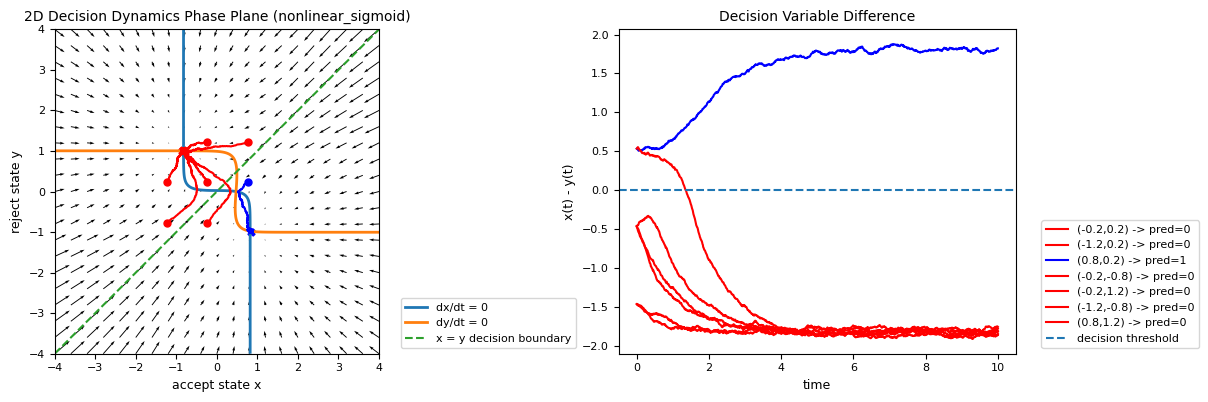

In [78]:
row = df_reaction.iloc[150]
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

demo = twoddynamics.run_single_trial_demo_2d(
    row,
    auto_pressure_reduction=0.5,
    density_pressure_gain=0.5,
    time_pressure_gain=1.0,

    alpha_coherence=1.0,
    alpha_intensity=0.5,
    alpha_ci=0.2,
    alpha_density=0.2,

    beta_pressure=1.0,
    beta_density=0.5,
    beta_time_pressure=1.5,
    beta_low_coherence=0.5,

    lam_x=1.217,
    lam_y=0.996,
    w_xy=3.637,
    w_yx=2.790,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,

    model="nonlinear_sigmoid",
)

In [77]:
df_type_two = df_reaction[df_reaction["recommendation_category"] == 2]

df_sim = twoddynamics.simulate_dataframe_2d(
    df_reaction,
    
    auto_pressure_reduction=0.5,
    density_pressure_gain=0.5,
    time_pressure_gain=1.0,

    alpha_coherence=1.0,
    alpha_intensity=0.5,
    alpha_ci=0.2,
    alpha_density=0.2,

    beta_pressure=1.0,
    beta_density=0.5,
    beta_time_pressure=1.5,
    beta_low_coherence=0.5,

    lam_x=1.217,
    lam_y=0.996,
    w_xy=3.637,
    w_yx=2.790,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,

    model="nonlinear_sigmoid",
)
# print(df_sim.head())

valid = df_sim.dropna(subset=["accept_true"])
acc = (valid["accept_pred"] == valid["accept_true"]).mean()
print("original acceptance rate =", valid["accept_true"].mean())
print("accuracy =", acc)

original acceptance rate = 0.6815642458100558
accuracy = 0.7513966480446927


In [73]:
df_search = twoddynamics.random_search_twod(df_reaction, twoddynamics, n_iter=300, seed=123)
print(df_search.head(10)[[
    "score", "acc", "bal_acc", "pred_rate", "true_rate",
    "alpha_ci", "alpha_density",
    "beta_pressure", "beta_time_pressure",
    "w_xy", "w_yx", "lam_x", "lam_y"
]])

[20/300] best score = 0.5764, acc = 0.7542, bal_acc = 0.7098
[40/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[60/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[80/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[100/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[120/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[140/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[160/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[180/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[200/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[220/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[240/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[260/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[280/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
[300/300] best score = 0.5810, acc = 0.7514, bal_acc = 0.7171
      score       acc   bal_acc  pred_rate  true_rate  alpha_ci  \
0  0.58

In [76]:
from scipy.optimize import differential_evolution

param_names = [
    "alpha_ci", "alpha_density",
    "beta_pressure", "beta_time_pressure",
    "w_xy", "w_yx", "lam_x", "lam_y"
]

bounds = [
    (0.2, 1.5),   # alpha_ci
    (0.0, 1.0),   # alpha_density
    (0.1, 1.5),   # beta_pressure
    (0.2, 2.5),   # beta_time_pressure
    (0.5, 4.0),   # w_xy
    (0.5, 4.0),   # w_yx
    (0.6, 1.6),   # lam_x
    (0.6, 1.6),   # lam_y
]

fixed_params = {
    "auto_pressure_reduction": 0.5,
    "density_pressure_gain": 0.5,
    "time_pressure_gain": 0.8,

    "alpha_coherence": 1.5,
    "alpha_intensity": 0.5,

    "beta_density": 0.5,
    "beta_low_coherence": 0.5,

    "sigma_x": 0.04,
    "sigma_y": 0.04,
    "T": 10.0,
    "decision_threshold": 0.0,
    "model": "nonlinear_sigmoid",
}

def objective(vec):
    params = dict(fixed_params)
    for k, v in zip(param_names, vec):
        params[k] = float(v)

    df_sim = twoddynamics.simulate_dataframe_2d(df_reaction, **params)
    valid = df_sim.dropna(subset=["accept_true"]).copy()

    if len(valid) == 0:
        return 1e6

    metrics = twoddynamics.compute_objective(valid)

    return -metrics["score"]

result = differential_evolution(
    objective,
    bounds=bounds,
    seed=123,
    maxiter=30,
    popsize=10,
    polish=True,
    disp=True,
)

best_vec = result.x
best_params = dict(fixed_params)
for k, v in zip(param_names, best_vec):
    best_params[k] = float(v)

print(best_params)
print("best objective =", -result.fun)

differential_evolution step 1: f(x)= -0.5792600677557067
differential_evolution step 2: f(x)= -0.5806937508736582
differential_evolution step 3: f(x)= -0.5806937508736582
differential_evolution step 4: f(x)= -0.5806937508736582
differential_evolution step 5: f(x)= -0.5810198463004291
differential_evolution step 6: f(x)= -0.5842233500111668
Polishing solution with 'L-BFGS-B'
{'auto_pressure_reduction': 0.5, 'density_pressure_gain': 0.5, 'time_pressure_gain': 0.8, 'alpha_coherence': 1.5, 'alpha_intensity': 0.5, 'beta_density': 0.5, 'beta_low_coherence': 0.5, 'sigma_x': 0.04, 'sigma_y': 0.04, 'T': 10.0, 'decision_threshold': 0.0, 'model': 'nonlinear_sigmoid', 'alpha_ci': 0.22750843466000747, 'alpha_density': 0.21798658568760731, 'beta_pressure': 1.0800045594365142, 'beta_time_pressure': 1.5137461037128368, 'w_xy': 3.637605469085696, 'w_yx': 2.7902372156613517, 'lam_x': 1.2178945730681792, 'lam_y': 0.996255928631535}
best objective = 0.5842233500111668


In [436]:
valid = df_sim.dropna(subset=["accept_true"]).copy()

print("true accept rate =", valid["accept_true"].mean())
print("pred accept rate =", valid["accept_pred"].mean())

cm = pd.crosstab(
    valid["accept_true"],
    valid["accept_pred"],
    rownames=["true"],
    colnames=["pred"],
    dropna=False
)
print(cm)

true accept rate = 0.6815642458100558
pred accept rate = 0.6983240223463687
pred   0    1
true         
0     67   47
1     41  203


In [435]:
valid = df_sim.dropna(subset=["accept_true"]).copy()

print(valid[["f_x", "f_y"]].describe())
print("mean f_x =", valid["f_x"].mean())
print("mean f_y =", valid["f_y"].mean())
print("mean f_x - f_y =", (valid["f_x"] - valid["f_y"]).mean())

              f_x         f_y
count  358.000000  358.000000
mean     0.465678    0.216485
std      0.407717    0.906544
min     -0.390872   -1.544250
25%      0.204295   -0.415626
50%      0.458872    0.091574
75%      0.778244    0.828633
max      1.304402    2.190328
mean f_x = 0.4656778566930364
mean f_y = 0.2164847439459043
mean f_x - f_y = 0.24919311274713218
